In [4]:
import os

import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

import seaborn as sns
from ast import literal_eval

from typing import Dict, List, Optional, Tuple
from datetime import datetime, timedelta
import time

import glob
import json
import requests
from pprint import pprint

from concurrent.futures import ProcessPoolExecutor, as_completed
import logging

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.model_selection import RandomizedSearchCV

import multiprocessing as mp

# from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from linearmodels.panel import PanelOLS

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

import sklearn.inspection
from sklearn.inspection import PartialDependenceDisplay
from matplotlib import rcParams
# rcParams['figure.figsize'] = 6,6

# import plotly.express as px
import time
import requests
import re
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

In [5]:
# !pip install --upgrade pip
# !pip install linearmodels
# !pip install xlsxwriter

In [6]:
np.random.seed(42)

In [7]:
def grid_search_cv(param_grid, model, X_train_scaled, y_train, X_test_scaled, y_test):

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_scaled, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    print("Best parameters found:", best_params)
    print("Best cross-validation score (negative MSE):", grid_search.best_score_)

    model_pred = best_model.predict(X_test_scaled)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    print(f"Test RMSE: {model_rmse:.4f}")
    print(f"Test R²: {model_r2:.4f}")
    
    return best_params, best_model

In [8]:
def prepare_data(df, features, target_col='next_day_3_log_return'):

    data = df.copy()
    
    data = data.dropna(subset=[target_col])
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    X = data[features]
    y = data[target_col]
    
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            if X[col].dtype in ['int64', 'float64']:
#                 X[col].fillna(X[col].median(), inplace=True)
#                 X[col].fillna(X[col].mean(), inplace=True)
                X[col].fillna(0., inplace=True)
    
    return X, y

def data_train_test_split(df, features, target_col, q=2, test_size=0.1):
    X, y = prepare_data(df, features, target_col=target_col)

    y_bins = pd.qcut(y, q=q, labels=False, duplicates='drop')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, 
#         stratify=y_bins
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    print(round(y_train.mean(), 3), round(y_test.mean(), 3))
    
    return X_train_scaled, X_test_scaled, y_train, y_test

In [9]:
def scatter_regplot(x, y, **kws):
    ax = plt.gca()
    # Scatter plot
    ax.scatter(x, y, alpha=0.6, s=30, edgecolor='w', linewidth=0.5)
    # Линия регрессии
    sns.regplot(x=x, y=y, scatter=False, 
                line_kws={'color': 'red', 'alpha': 0.8, 'linewidth': 2})
    r, p_value = stats.pearsonr(x, y)
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                fontsize=9)

def diag_kde(x, **kws):
    ax = plt.gca()
    sns.histplot(x, kde=True, stat="density", alpha=0.7, ax=ax)

    mean_val = x.mean()
    median_val = x.median()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.3f}')
    if ax.get_subplotspec().is_first_row() and ax.get_subplotspec().is_first_col():
        ax.legend(loc='upper right', fontsize=8)

def lower_hexbin(x, y, **kws):
    ax = plt.gca()
    hb = ax.hexbin(x, y, gridsize=30, cmap='Blues', alpha=0.8, mincnt=1)
    plt.colorbar(hb, ax=ax, shrink=0.7)

In [10]:
def calculate_pvalues(df, method='pearson'):
    n = df.shape[1]
    p_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                p_matrix[i, j] = 0
            else:
                if method == 'pearson':
                    corr, p_value = pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
                elif method == 'spearman':
                    corr, p_value = spearmanr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
    return pd.DataFrame(p_matrix, index=df.columns, columns=df.columns)

def annotate_with_pvalues(corr_matrix, p_matrix):
    annot_matrix = np.empty_like(corr_matrix, dtype=object)
    n = corr_matrix.shape[0]
    
    for i in range(n):
        for j in range(n):
            if i == j:
                annot_matrix[i, j] = '1.00'
            elif mask[i, j]: 
                annot_matrix[i, j] = ''
            else:
                corr_val = corr_matrix.iloc[i, j]
                p_val = p_matrix.iloc[i, j]
                
                stars = ''
                if p_val < 0.01:
                    stars = '***'
                elif p_val < 0.05:
                    stars = '**'
                elif p_val < 0.1:
                    stars = '*'
                
                annot_matrix[i, j] = f'{corr_val:.2f}{stars}'
    
    return annot_matrix

def plot_corr_matrix(corr_matrix, mask, annotations, title='Correlation with p-values'):
    plt.figure(figsize=(12, 10))
    heatmap = sns.heatmap(corr_matrix,
                mask=mask,
                annot=annotations,
                cmap='RdBu_r',
                center=0,
                square=True,
                fmt='', 
                linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 9})

    plt.title(title, fontsize=16, pad=20)

    legend_text = '\n'.join([
        '*** p < 0.01',
        '** p < 0.05', 
        '* p < 0.1',
    #     'Без звездочек: p ≥ 0.05'
    ])
    plt.figtext(0.72, 0.92, legend_text, fontsize=10, 
               bbox=dict(boxstyle="round, pad=0.5", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()

def get_coordinates_photon(zip_code, state=None):
    try:
        if state:
            query = f"{zip_code}, {state}, USA"
        else:
            query = f"{zip_code}, USA"
        
        url = f"https://photon.komoot.io/api/?q={query}&limit=1"
        response = requests.get(url, timeout=10)
        data = response.json()
        
        if data['features']:
            coords = data['features'][0]['geometry']['coordinates']
            return coords[1], coords[0]  # lat, lon
        return None, None
    except Exception as e:
        print(f"Error geocoding {zip_code}: {e}")
        return None, None

def get_coordinates_with_retry(zip_code, state, max_retries=3):
    for attempt in range(max_retries):
        try:
            lat, lon = get_coordinates_photon(zip_code, state)
            if lat and lon:
                return lat, lon
        except Exception as e:
            print(f"Attempt {attempt + 1} failed for {zip_code}: {e}")
            time.sleep(2)
    return None, None

def parse_industry_file_with_expanded_codes(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    
    industry_blocks = re.split(r'\n\s*\n', content.strip())
    
    data = []
    
    for block in industry_blocks:
        lines = block.strip().split('\n')
        
        if len(lines) < 2:
            continue
        
        first_line = lines[0].strip()
        match = re.match(r'(\d+)\s+(\w+)\s+(.+)', first_line)
        
        if match:
            industry_num = int(match.group(1))
            industry_code = match.group(2)
            industry_name = match.group(3).strip()
            
            # Обрабатываем диапазоны кодов
            for line in lines[1:]:
                line = line.strip()
                if line and re.match(r'\d{4}-\d{4}', line):
                    start, end = map(int, line.split('-'))
                    
                    # Создаем отдельную запись для каждого кода в диапазоне
                    for code in range(start, end + 1):
                        data.append({
                            'industry_number': industry_num,
                            'industry_code': industry_code,
                            'industry_name': industry_name,
                            'sic_code': code
                        })
    
    return pd.DataFrame(data)

    
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix,
#             mask=mask,
#             annot=True,
#             cmap='RdBu_r',
#             center=0,
#             square=True,
#             fmt='.2f',
#             linewidths=0.5,
#             cbar_kws={'shrink': 0.8})

# plt.title('Correlation', fontsize=16, pad=20)
# plt.tight_layout()
# plt.show()

In [11]:
def ols_with_cluster(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results

In [12]:
class color:
    PURPLE = '\033[95m'
    CYAN = '\033[96m'
    DARKCYAN = '\033[36m'
    BLUE = '\033[94m'
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'
    END = '\033[0m'

## Data

In [9]:
sent_df = pd.read_csv("frankel_llama_sentiments_full_sample.tsv.gz", sep='\t', compression='gzip')

In [10]:
sent_df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk,SIC,industry_number,industry_code,industry_name,sic_code
0,b'001004',2002-05-31,11.44,31.870,310.235,0.903180,20000.0,54594.0,2002-08-26,b'1750_0000912057-02-033450',364.59280,0.850908,32389900.0,26860.0,1.205879,-0.002825,0.0,-0.001721,0.004142,0.007198,-0.269461,0.055273,0.027433,0.336617,0.006738,0.008455,0.006816,2002.0,5.898781,0.604134,0000912057-02-033450,1750,20020826,0.058687,0.195582,-0.136895,0.136032,0.187103,-0.051071,0.197464,0.101707,0.095757,0.098328,0.313736,-0.215408,0.062782,0.309700,-0.246918,0.124844,0.280563,-0.155720,0.055691,0.270439,-0.214748,0.111652,0.233459,-0.121807,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
1,b'001004',2003-05-31,4.50,31.851,294.988,0.900913,20000.0,54594.0,2003-08-18,b'1750_0001047469-03-028005',143.32950,2.058111,21138500.0,31850.0,0.663689,-0.000024,0.0,0.144115,0.003915,0.007516,-0.315068,0.052143,0.025575,0.341840,0.002241,-0.003203,0.002330,2003.0,4.965146,0.384908,0001047469-03-028005,1750,20030818,0.251242,0.105926,0.145316,0.153076,0.123199,0.029877,0.200882,0.121155,0.079727,0.186245,0.246414,-0.060169,0.204582,0.150684,0.053898,0.252907,0.108986,0.143921,0.129883,0.237461,-0.107578,0.176495,0.195606,-0.019112,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
2,b'001004',2004-05-31,9.58,32.245,301.684,0.901062,20000.0,54594.0,2004-07-22,b'1750_0001047469-04-023905',308.90710,0.976617,41549083.0,32245.0,1.288543,0.000483,0.0,-0.050975,0.004134,0.007463,-0.287037,0.055412,0.026901,0.346380,0.047686,0.114837,-0.000087,2004.0,5.733041,2.809282,0001047469-04-023905,1750,20040722,0.177849,0.112457,0.065392,0.183945,0.080505,0.103439,0.200584,0.090813,0.109772,0.125092,0.302937,-0.177845,0.087914,0.300018,-0.212105,0.124878,0.294327,-0.169449,0.074173,0.278572,-0.204399,0.124195,0.244942,-0.120747,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
3,b'001004',2005-05-31,16.04,32.586,314.744,1.000000,20000.0,54594.0,2005-07-22,b'1750_0001104659-05-033688',522.67944,0.602174,47055900.0,32438.0,1.450641,0.001064,0.0,-0.003768,0.004717,0.007433,-0.223529,0.053891,0.024253,0.379268,0.005943,0.044268,-0.001063,2005.0,6.258968,0.715961,0001104659-05-033688,1750,20050722,0.241506,0.040220,0.201285,0.165558,0.071747,0.093811,0.178215,0.073090,0.105125,0.140617,0.284660,-0.144043,0.105381,0.273033,-0.167652,0.178501,0.208374,-0.029873,0.087654,0.247326,-0.159672,0.129677,0.219227,-0.089550,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
4,b'001004',2006-05-31,24.08,36.654,422.717,1.000000,20000.0,54594.0,2006-07-17,b'1750_0001104659-06-047248',882.62832,0.478930,97373000.0,36461.0,2.670607,0.001258,0.0,0.000631,0.005518,0.009995,-0.288557,0.054063,0.027553,0.324823,-0.004829,-0.014739,-0.005074,2006.0,6.782904,-0.670415,0001104659-06-047248,1750,20060717,0.261249,0.072720,0.188529,0.212341,0.093018,0.119324,0.181458,0.099716,0.081741,0.163521,0.229065,-0.065544,0.125561,0.220493,-0.094933,0.143944,0.156502,-0.012558,0.115681,0.192966,-0.077286,0.180267,0.161652,0.018616,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
...,...,...,...,...,...,...,...,...,...,...,..

In [11]:
sent_df['FILING_DATE'].astype(str).str[:4].value_counts(normalize=True).sort_index()

1996    0.020425
1997    0.032899
1998    0.034180
1999    0.032667
2000    0.031957
2001    0.029549
2002    0.033455
2003    0.043536
2004    0.041050
2005    0.045821
2006    0.047735
2007    0.050684
2008    0.051054
2009    0.049588
2010    0.048831
2011    0.046130
2012    0.045574
2013    0.042038
2014    0.044277
2015    0.046145
2016    0.046238
2017    0.045296
2018    0.045620
2019    0.045250
Name: FILING_DATE, dtype: float64

In [13]:
target = 'car01'
# control_variables = ['mve', 'ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']
control_variables = ['ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']

lm_tone = ['tone', 'tone_pos', 'tone_neg']
harv_tone = ['tone_harvard', 'tone_posharvard', 'tone_negharvard']
frankel_variables = ['rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'factorpred_car01']
llama = [col for col in sent_df.columns if 'polarity' in col]
len(llama)

8

In [66]:
df = pd.read_sas('finaldata_10k.sas7bdat')

In [15]:
# some_cols = list(set(df.columns) - set(control_variables) - set(lm_tone) - set(harv_tone) - set(frankel_variables) - set([target]) - set(['year', 'datadate', 'filename', 'date_filed', 'mve', 'gvkey']))
# some_cols

In [16]:
# for f in some_cols:
#     plt.figure(figsize=(6, 4))
#     plt.title(f, weight='bold')
#     df[f].hist(bins=50, histtype='step', density=True)
#     plt.show()

In [35]:
# for f in llama:
#     plt.figure(figsize=(6, 4))
#     plt.title(f, weight='bold')
#     sent_df[f].hist(bins=50, histtype='step', density=True)
#     plt.show()

In [33]:
# for column in llama:
#     df_[column] = winsorize(df_[column], limits=[0.01, 0.01])
# sent_df.shape

## Table 3 Panel A

In [17]:
results = ols_with_cluster(sent_df, 'car01', ['tone'] + control_variables, 'gvkey')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     26.43
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           3.97e-36
Time:                        18:15:03   Log-Likelihood:             1.0311e+05
No. Observations:               64774   AIC:                        -2.062e+05
Df Residuals:                   64766   BIC:                        -2.061e+05
Df Model:                           7                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019      0.001     -1.555      0.1

## Table 3 Panel B

In [343]:
def fit_one_factor(df, sentiment_features, control_variables, target='car01'):
    features_res = {}
    
    for f in sentiment_features:
        results = ols_with_cluster(df, target, [f] + control_variables, 'gvkey')
        features_res[f] = {}
        features_res[f]['model'] = results
        features_res[f]['coef'] = round(results.params[1], 3)
        features_res[f]['t'] = round(results.tvalues[1], 3)
        features_res[f]['r2_adj'] = round(100*results.rsquared_adj, 3)
        pval = round(results.pvalues[1], 3)
        
        features_res[f]['pval'] = pval
        if pval <= 0.01:
            sgnf = '***'
        elif 0.01 < pval <= 0.05:
            sgnf = '**'
        elif 0.05 < pval <= 0.1:
            sgnf = '*'
        else:
            sgnf = ''
        features_res[f]['sgnf'] = sgnf
        
    table_res = pd.DataFrame(features_res).T.drop('model', axis=1)
    table_res['coef'] = table_res['coef'].astype(str) + table_res['sgnf']
    table_res = table_res[['coef', 't', 'r2_adj', 'pval']]
        
    return features_res, table_res

In [46]:
llama = [col for col in sent_df.columns if 'polarity' in col or 'positive' in col or 'negative' in col]

sentiment_features = lm_tone + harv_tone + frankel_variables + llama
len(llama), len(sentiment_features)

(24, 34)

In [40]:
sent_df['FILING_DATE'] = sent_df['FILING_DATE'].astype(str)

In [74]:
_, early_period1 = fit_one_factor(df[df['year'] <= 2008], lm_tone + harv_tone + frankel_variables, control_variables)
_, early_period2 = fit_one_factor(sent_df[sent_df['year'] <= 2008], llama, control_variables)
early_period_res = pd.concat([early_period1, early_period2], axis=0)

print(color.BOLD + 'Early sample period (1996-2008)' + color.END)
early_period_res

Early sample period (1996-2008)


,coef,t,r2_adj,pval
tone,0.003***,2.711,0.791,0.007
tone_pos,-0.359**,-2.15,0.785,0.032
tone_neg,-0.234***,-3.479,0.803,0.001
tone_harvard,-0.001,-0.219,0.774,0.827
tone_posharvard,-0.027,-0.971,0.776,0.331
tone_negharvard,-0.003,-0.188,0.774,0.851
rfpred_car01,0.107***,4.368,0.846,0.0
svrpred_car01,0.009*,1.758,0.785,0.079
sldapred_car01,0.128***,2.733,0.798,0.006
factorpred_car01,0.001***,3.136,0.807,0.002


In [75]:
_, extra_period1 = fit_one_factor(df[df['year'] > 2008], lm_tone + harv_tone + frankel_variables, control_variables)
_, extra_period2 = fit_one_factor(sent_df[sent_df['year'] > 2008], llama, control_variables)
extra_period_res = pd.concat([extra_period1, extra_period2], axis=0)

print(color.BOLD + 'Extra sample period (2009-2019)' + color.END)
extra_period_res

Extra sample period (2009-2019)


,coef,t,r2_adj,pval
tone,-0.002,-1.02,0.331,0.308
tone_pos,0.033,0.125,0.328,0.901
tone_neg,0.099,1.155,0.332,0.248
tone_harvard,-0.007***,-2.698,0.347,0.007
tone_posharvard,-0.034,-0.864,0.33,0.387
tone_negharvard,0.059**,2.149,0.339,0.032
rfpred_car01,0.032,1.311,0.338,0.19
svrpred_car01,0.002,0.406,0.329,0.684
sldapred_car01,0.101*,1.938,0.341,0.053
factorpred_car01,0.001,1.347,0.338,0.178


In [76]:
_, full_sample = fit_one_factor(sent_df, sentiment_features, control_variables)

print(color.BOLD + 'Full sample period (1996-2019)' + color.END)
full_sample

Full sample period (1996-2019)


,coef,t,r2_adj,pval
tone,0.001,1.107,0.413,0.268
tone_pos,-0.057,-0.345,0.411,0.73
tone_neg,-0.033,-0.603,0.411,0.547
tone_harvard,-0.005***,-2.908,0.423,0.004
tone_posharvard,-0.014,-0.589,0.411,0.556
tone_negharvard,0.052**,2.48,0.419,0.013
rfpred_car01,0.067***,3.563,0.447,0.0
svrpred_car01,0.005,1.134,0.414,0.257
sldapred_car01,0.139***,3.769,0.437,0.0
factorpred_car01,0.001***,3.216,0.437,0.001


In [206]:
early_period_res.columns

Index(['coef', 't', 'r2_adj', 'pval'], dtype='object')

In [210]:
level0 = ['Early sample period (1996 -- 2008)'] * len(early_period_res.columns) 
level1 = list(early_period_res.columns)
early_period_res.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['Extra sample period (2009 -- 2019)'] * len(extra_period_res.columns) 
level1 = list(extra_period_res.columns)
extra_period_res.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['Full sample period (1996 -- 2019)'] * len(full_sample.columns) 
level1 = list(full_sample.columns)
full_sample.columns = pd.MultiIndex.from_arrays([level0, level1])

In [214]:
res_to_save = pd.concat([early_period_res, extra_period_res, full_sample], axis=1)
res_to_save

Early sample period (1996 -- 2008)                \
                                                        coef      t r2_adj   
tone                                                0.003***  2.711  0.791   
tone_pos                                            -0.359**  -2.15  0.785   
tone_neg                                           -0.234*** -3.479  0.803   
tone_harvard                                          -0.001 -0.219  0.774   
tone_posharvard                                       -0.027 -0.971  0.776   
tone_negharvard                                       -0.003 -0.188  0.774   
rfpred_car01                                        0.107***  4.368  0.846   
svrpred_car01                                         0.009*  1.758  0.785   
sldapred_car01                                      0.128***  2.733  0.798   
factorpred_car01                                    0.001***  3.136  0.807   
positive_general                                    0.021***  6.868  0.832   
negative_general                                   -0.037***  -6.32  0.831   
polarity_general                                    0.015***   6.91  0.844   
positive_revenue                                      -0.007 -1.199  0.684   
negative_revenue                                     -0.01** -1.958  0.696   
polarity_revenue                                       0.004   0.87  0.683   
positive_profit                                       -0.001 -0.141   0.68   
negative_profit                                    -0.021*** -2.607  0.704   
polarity_profit                                      0.015**  2.038  0.696   
positive_strategic_risk                             0.008***  5.035  0.755   
negative_strategic_risk                            -0.006*** -3.266  0.724   
polarity_strategic_risk                             0.005***  4.601  0.756   
positive_operational_risk                           0.008***  4.613  0.749   
negative_operational_risk                          -0.007*** -3.551  0.736   
polarity_operational_risk                           0.005***  4.675  0.764   
positive_financial_risk                             0.005***  3.129  0.718   
negative_financial_risk                            -0.012***  -3.48  0.739   
polarity_financial_risk                             0.005***  3.915  0.744   
positive_reputation_risk                             0.009**  2.441  0.699   
negative_reputation_risk                              -0.002 -0.903  0.682   
polarity_reputation_risk                              0.002*  1.675  0.689   
positive_compliance_risk                            0.006***  3.523  0.717   
negative_compliance_risk                            -0.01*** -3.871  0.746   
polarity_compliance_risk                            0.005***  4.224  0.744   

                                 Extra sample period (2009 -- 2019)         \
                            pval                               coef      t   
tone                       0.007                             -0.002  -1.02   
tone_pos                   0.032                              0.033  0.125   
tone_neg                   0.001                              0.099  1.155   
tone_harvard               0.827                          -0.007*** -2.698   
tone_posharvard            0.331                             -0.034 -0.864   
tone_negharvard            0.851                            0.059**  2.149   
rfpred_car01                 0.0                              0.032  1.311   
svrpred_car01              0.079                              0.002  0.406   
sldapred_car01             0.006                             0.101*  1.938   
factorpred_car01           0.002                              0.001  1.347   
positive_general             0.0                           0.024***   7.65   
negative_general             0.0                          -0.036*** -6.261   
polarity_general             0.0                           0.016***  7.343   
positive_revenue           0.231               

In [228]:
# excel_file = 'regressions/all_regressions.xlsx'

# with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
#     res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)

## Panel data
### with FE and without FE

In [110]:
# from linearmodels.panel import generate_panel_data
# panel_data = generate_panel_data()

In [111]:
# panel_data.data

In [99]:
df_panel = sent_df.set_index(['gvkey', 'year'])
df_panel.tail()

datadate  prcc_f     csho       ceq   instown   permco  \
gvkey     year                                                               
b'317264' 2017.0  2017-03-31   10.53   54.975   976.002  0.000000  54852.0   
          2018.0  2018-03-31    7.49   55.090   959.413  0.565377  54852.0   
          2019.0  2019-03-31    6.42   55.168   912.683  0.529435  54852.0   
b'318728' 2018.0  2017-12-31   51.71  199.853  9208.000  0.000000  55804.0   
          2019.0  2018-12-31   39.83  197.100  8276.000  0.722051  55804.0   

                   permno  date_filed                         filename  \
gvkey     year                                                           
b'317264' 2017.0  14642.0  2017-06-14  b'1596993_0001596993-17-000010'   
          2018.0  14642.0  2018-06-28  b'1596993_0001596993-18-000015'   
          2019.0  14642.0  2019-05-30  b'1596993_0001596993-19-000010'   
b'318728' 2018.0  16496.0  2018-02-26  b'1527469_0001527469-18-000011'   
          2019.0  16496.0  2019-02-27  b'1527469_0001527469-19-000007'   

                          mve       btm       volume    SHROUT  turnover  \
gvkey     year                                                             
b'317264' 2017.0    578.88675  1.685998   59346255.0   54967.0  1.079671   
          2018.0    412.62410  2.325150   58762972.0   55107.0  1.066343   
          2019.0    354.17856  2.508930   40707109.0   55167.0  0.737889   
b'318728' 2018.0  10334.39863  0.891005  334320819.0  142348.0  2.348616   
          2019.0   7850.49300  1.054201  338861633.0  164849.0  2.055588   

                  pre_alpha  nasdaq     car01  tone_pos  tone_neg      tone  \
gvkey     year                                                                
b'317264' 2017.0  -0.000467     0.0 -0.029018  0.005495  0.014015 -0.436735   
          2018.0  -0.000395     0.0 -0.047430  0.005525  0.014667 -0.452713   
          2019.0   0.000974     0.0 -0.027795  0.005649  0.013585 -0.412628   
b'318728' 2018.0  -0.000431     0.0 -0.001046  0.007346  0.013908 -0.308759   
          2019.0  -0.000151     0.0  0.006164  0.007526  0.013676 -0.290089   

                  tone_posharvard  tone_negharvard  tone_harvard  \
gvkey     year                                                     
b'317264' 2017.0         0.053671         0.033333      0.233754   
          2018.0         0.052688         0.033028      0.229364   
          2019.0         0.054438         0.032027      0.259187   
b'318728' 2018.0         0.077755         0.048643      0.230316   
          2019.0         0.077833         0.049895      0.224715   

                  rfpred_car01  svrpred_car01  sldapred_car01    ln_mve  \
gvkey     year                                                            
b'317264' 2017.0     -0.007481       0.061267       -0.005647  6.361107   
          2018.0     -0.012188       0.007985        0.001820  6.022537   
          2019.0     -0.016984      -0.063728        0.008236  5.869801   
b'318728' 2018.0      0.001199       0.015440        0.010414  9.243233   
          2019.0      0.001628      -0.119722       -0.002462  8.968332   

                  factorpred_car01               ACC_NUM      CIK FILING_DATE  \
gvkey     year                                                                  
b'317264' 2017.0         -0.123893  0001596993-17-000010  1596993    20170614   
          2018.0         -0.338591  0001596993-18-000015  1596993    20180628   
          2019.0         -0.797175  0001596993-19-000010  1596993    20190530   
b'318728' 2018.0          0.560623  0001527469-18-000011  1527469    20180226   
          2019.0         -1.054262  0001527469-19-000007  1527469    20190227   

                  positive_general  negative_general  polarity_general  \
gvkey     year                                                           
b'317264' 2017.0          0.095707          0.200253         -0.104546   
          2018.0          0.249641          0.124596          0.125046   


In [250]:
def panel_ols_fe(panel_data, target, x_vars, entity_effects=True, time_effects=True):
    
    if entity_effects and time_effects:
        formula = f"{target} ~ EntityEffects + TimeEffects + " + " + ".join(x_vars)
    elif entity_effects and not time_effects:
        formula = f"{target} ~ EntityEffects + " + " + ".join(x_vars)
    elif time_effects and not entity_effects:
        formula = f"{target} ~ TimeEffects + " + " + ".join(x_vars)
    else:
        formula = f"{target} ~ " + " + ".join(x_vars)
        
    model = PanelOLS.from_formula(formula, panel_data, drop_absorbed=True)
    results = model.fit()
    return results


def fit_one_factor_panel(panel_data, target, sentiment_features, control_variables, entity_effects=True, time_effects=True):
    features_res = {}
    
    for f in tqdm(sentiment_features):
#         print(f)
        results = panel_ols_fe(panel_data, target, [f] + control_variables, entity_effects, time_effects)
        features_res[f] = {}
        features_res[f]['model'] = results
        features_res[f]['coef'] = round(results.params[f], 3)
        features_res[f]['t'] = round(results.tstats[f], 3)
        features_res[f]['r2'] = round(100*results.rsquared, 3)
        pval = round(results.pvalues[f], 3)
        
        features_res[f]['pval'] = pval
        if pval <= 0.01:
            sgnf = '***'
        elif 0.01 < pval <= 0.05:
            sgnf = '**'
        elif 0.05 < pval <= 0.1:
            sgnf = '*'
        else:
            sgnf = ''
        features_res[f]['sgnf'] = sgnf
        
    table_res = pd.DataFrame(features_res).T.drop('model', axis=1)
    table_res['coef'] = table_res['coef'].astype(str) + table_res['sgnf']
    table_res = table_res[['coef', 't', 'r2', 'pval']]
        
    return features_res, table_res

In [183]:
_, panel_res = fit_one_factor_panel(df_panel, target, sentiment_features, control_variables, entity_effects=True, time_effects=True)

100%|██████████| 34/34 [00:35<00:00,  1.05s/it]


In [184]:
panel_res

,coef,t,r2,pval
tone,0.004**,2.019,0.306,0.044
tone_pos,0.328,1.179,0.301,0.239
tone_neg,-0.172,-1.483,0.303,0.138
tone_harvard,-0.004,-1.151,0.301,0.25
tone_posharvard,-0.095,-1.533,0.303,0.125
tone_negharvard,0.008,0.197,0.299,0.844
rfpred_car01,-0.485***,-32.215,2.13,0.0
svrpred_car01,-0.072***,-19.706,0.992,0.0
sldapred_car01,-0.256***,-6.377,0.372,0.0
factorpred_car01,-0.006***,-26.707,1.565,0.0


In [202]:
_, panel_res_without_effects = fit_one_factor_panel(df_panel, target, sentiment_features, control_variables, entity_effects=False, time_effects=False)

100%|██████████| 34/34 [00:09<00:00,  3.68it/s]


In [203]:
panel_res_without_effects

,coef,t,r2,pval
tone,0.002,1.425,0.451,0.154
tone_pos,-0.177,-1.518,0.451,0.129
tone_neg,-0.066,-1.31,0.451,0.19
tone_harvard,-0.005***,-3.395,0.466,0.001
tone_posharvard,-0.031*,-1.859,0.453,0.063
tone_negharvard,0.027,1.327,0.451,0.185
rfpred_car01,0.068***,4.969,0.486,0.0
svrpred_car01,0.005,1.452,0.451,0.146
sldapred_car01,0.142***,4.242,0.476,0.0
factorpred_car01,0.001***,4.221,0.475,0.0


In [216]:
_, panel_res_with_entity = fit_one_factor_panel(df_panel, target, sentiment_features, control_variables, entity_effects=True, time_effects=False)

100%|██████████| 34/34 [00:10<00:00,  3.26it/s]


In [217]:
panel_res_with_entity

,coef,t,r2,pval
tone,0.001,0.662,0.299,0.508
tone_pos,0.384,1.413,0.302,0.158
tone_neg,0.035,0.375,0.299,0.708
tone_harvard,-0.008***,-2.863,0.313,0.004
tone_posharvard,-0.008,-0.143,0.299,0.887
tone_negharvard,0.074**,2.33,0.308,0.02
rfpred_car01,-0.483***,-32.148,2.122,0.0
svrpred_car01,-0.072***,-19.762,0.995,0.0
sldapred_car01,-0.203***,-5.411,0.351,0.0
factorpred_car01,-0.006***,-26.818,1.574,0.0


In [218]:
_, panel_res_with_time = fit_one_factor_panel(df_panel, target, sentiment_features, control_variables, entity_effects=False, time_effects=True)

100%|██████████| 34/34 [00:10<00:00,  3.35it/s]


In [222]:
panel_res_with_time

,coef,t,r2,pval
tone,0.003**,2.049,0.39,0.04
tone_pos,-0.072,-0.475,0.383,0.635
tone_neg,-0.121*,-1.909,0.389,0.056
tone_harvard,-0.004**,-1.996,0.389,0.046
tone_posharvard,-0.044,-1.487,0.386,0.137
tone_negharvard,0.033,1.203,0.385,0.229
rfpred_car01,0.066***,4.783,0.418,0.0
svrpred_car01,0.005,1.505,0.387,0.132
sldapred_car01,0.134***,3.721,0.404,0.0
factorpred_car01,0.001***,4.155,0.41,0.0


In [224]:
level1 = list(panel_res.columns)
level1

['coef', 't', 'r2', 'pval']

In [225]:
level0 = ['PanelOLS Entity + Time Effects'] * len(level1) 
panel_res.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['PanelOLS Pooled (no effects)'] * len(cols) 
panel_res_without_effects.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['PanelOLS Entity Effects'] * len(cols) 
panel_res_with_entity.columns = pd.MultiIndex.from_arrays([level0, level1])

level0 = ['PanelOLS Time Effects'] * len(cols)
panel_res_with_time.columns = pd.MultiIndex.from_arrays([level0, level1])

In [226]:
panel_res_to_save = pd.concat([panel_res, panel_res_with_entity, panel_res_with_time, panel_res_without_effects], axis=1)
panel_res_to_save

PanelOLS Entity + Time Effects                 \
                                                    coef       t     r2   
tone                                             0.004**   2.019  0.306   
tone_pos                                           0.328   1.179  0.301   
tone_neg                                          -0.172  -1.483  0.303   
tone_harvard                                      -0.004  -1.151  0.301   
tone_posharvard                                   -0.095  -1.533  0.303   
tone_negharvard                                    0.008   0.197  0.299   
rfpred_car01                                   -0.485*** -32.215   2.13   
svrpred_car01                                  -0.072*** -19.706  0.992   
sldapred_car01                                 -0.256***  -6.377  0.372   
factorpred_car01                               -0.006*** -26.707  1.565   
positive_general                                0.021***   7.071  0.388   
negative_general                               -0.035***  -6.947  0.385   
polarity_general                                0.014***    7.36  0.396   
positive_revenue                                0.014***   2.783  0.313   
negative_revenue                               -0.017***  -4.288  0.332   
polarity_revenue                                0.015***   4.977  0.343   
positive_profit                                     0.01   1.297  0.302   
negative_profit                                -0.024***  -3.326  0.319   
polarity_profit                                 0.023***   3.844  0.325   
positive_strategic_risk                          0.005**   2.244  0.308   
negative_strategic_risk                          -0.004*  -1.903  0.305   
polarity_strategic_risk                          0.003**   2.363  0.309   
positive_operational_risk                       0.006***   2.942  0.314   
negative_operational_risk                      -0.007***  -3.053  0.315   
polarity_operational_risk                       0.004***   3.498  0.321   
positive_financial_risk                         0.005***   2.581  0.311   
negative_financial_risk                        -0.019***  -5.851   0.36   
polarity_financial_risk                         0.007***   4.553  0.336   
positive_reputation_risk                           0.004   1.045  0.301   
negative_reputation_risk                             0.0   0.142  0.299   
polarity_reputation_risk                           0.001   0.348  0.299   
positive_compliance_risk                           0.003   1.556  0.303   
negative_compliance_risk                         -0.005*  -1.889  0.305   
polarity_compliance_risk                          0.003*   1.945  0.305   

                                 PanelOLS Entity Effects                 \
                            pval                    coef       t     r2   
tone                       0.044                   0.001   0.662  0.299   
tone_pos                   0.239                   0.384   1.413  0.302   
tone_neg                   0.138                   0.035   0.375  0.299   
tone_harvard                0.25               -0.008***  -2.863  0.313   
tone_posharvard            0.125                  -0.008  -0.143  0.299   
tone_negharvard            0.844                 0.074**    2.33  0.308   
rfpred_car01                 0.0               -0.483*** -32.148  2.122   
svrpred_car01                0.0               -0.072*** -19.762  0.995   
sldapred_car01               0.0               -0.203***  -5.411  0.351   
factorpred_car01             0.0               -0.006*** -26.818  1.574   
positive_general             0.0                0.021***   7.244  0.393   
negative_general             0.0                -0.03***  -6.158  0.367   
polarity_general             0.0                0.014***   7.181  0.391   
positive_revenue           0.005                0.014***   2.779  0.312   
negative_revenue             0.0               -0.018***  -4.711  0.338   
polarity_revenue             0.0                0.

In [230]:
with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)
    panel_res_to_save.to_excel(writer, sheet_name='Panel one-factor regressions', index=True)

## Panel regressions by years

In [192]:
# fit_one_factor_panel(df_period, target, [tone], control_variables, entity_effects=True, time_effects=True)

In [193]:
# df_period

In [197]:
tone_res2 = {}

for tone in ['tone', 'rfpred_car01', 'polarity_general', 'polarity_revenue', 'polarity_financial_risk']:
    tone_year = []
    r2_year = []
    
    for year in range(1996, 2020):
        df_period = df_panel[df_panel['FILING_DATE'].str[:4] == str(year)].copy()
#         _, res_period = fit_one_factor(df_period, [tone], control_variables)
        _, res_period = fit_one_factor_panel(df_period, target, [tone], control_variables, entity_effects=False, time_effects=False)
        
        tone_year.append(res_period['t'].values[0])
        r2_year.append(res_period['r2'].values[0])
        
    tone_res2[tone] = {}
    tone_res2[tone]['t'] = np.abs(np.array(tone_year))
    tone_res2[tone]['r2'] = np.array(r2_year)

100%|██████████| 1/1 [00:00<00:00, 15.05it/s]


In [198]:
tone_res2.keys()
# ['polarity_financial_risk']['r2_adj']

dict_keys(['tone', 'rfpred_car01', 'polarity_general', 'polarity_revenue', 'polarity_financial_risk'])

In [955]:
# res_period = fit_one_factor(df_period, [tone], control_variables)

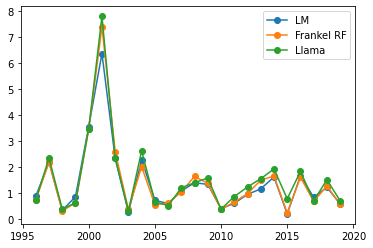

In [200]:
plt.figure()
plt.plot(range(1996, 2020), tone_res2['tone']['r2'], marker='o', label='LM')
plt.plot(range(1996, 2020), tone_res2['rfpred_car01']['r2'], marker='o', label='Frankel RF')
plt.plot(range(1996, 2020), tone_res2['polarity_general']['r2'], marker='o', label='Llama')        
# plt.plot(range(1996, 2020), tone_res['polarity_financial_risk'], marker='o', label='Llama financial risk')
plt.legend()
plt.show()
# tone_res2['tone']['r2_adj']

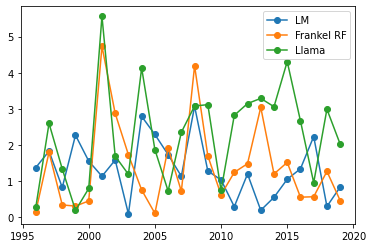

In [201]:
plt.figure()
plt.plot(range(1996, 2020), tone_res2['tone']['t'], marker='o', label='LM')
plt.plot(range(1996, 2020), tone_res2['rfpred_car01']['t'], marker='o', label='Frankel RF')
plt.plot(range(1996, 2020), tone_res2['polarity_general']['t'], marker='o', label='Llama')        
# plt.plot(range(1996, 2020), tone_res['polarity_financial_risk'], marker='o', label='Llama financial risk')
plt.legend()
plt.show()
# tone_res2['tone']['r2_adj']

# Segment models
## Industries

In [245]:
sent_df['industry_code'].value_counts().sort_values()

Chems     1474
Durbl     1519
Telcm     1592
Utils     1835
Enrgy     2761
NoDur     2875
Manuf     5933
Shops     6370
Hlth      7724
Other     9003
BusEq    11346
Money    12342
Name: industry_code, dtype: int64

In [247]:
industries = set(sent_df['industry_code'])
len(industries)

12

In [292]:
industries_results = {}

for industry in industries:
#     df_segment = df_panel[df_panel['industry_code'] == industry].copy()
#     _, res_seg = fit_one_factor_panel(df_segment, target, sentiment_features, control_variables, entity_effects=True, time_effects=True)

    df_segment = sent_df[sent_df['industry_code'] == industry].copy()
    _, res_seg = fit_one_factor(df_segment, sentiment_features, control_variables)

    industries_results[industry] = res_seg

In [293]:
industries_results.keys()

dict_keys(['Money', 'Shops', 'Enrgy', 'NoDur', 'Other', 'Chems', 'Telcm', 'Hlth', 'Manuf', 'Durbl', 'BusEq', 'Utils'])

In [294]:
for k, v in industries_results.items():
    level0 = [k] * len(level1) 
    v.columns = pd.MultiIndex.from_arrays([level0, level1])

In [295]:
industries_results['Money'].head()

Money                     
                    coef      t     r2   pval
tone                 0.0  0.099  0.494  0.921
tone_pos         -0.543* -1.752  0.519   0.08
tone_neg          -0.093 -0.958  0.503  0.338
tone_harvard      -0.001 -0.495  0.496  0.621
tone_posharvard    -0.05 -0.918  0.503  0.359

In [299]:
industries_res_to_save = pd.concat([v for v in industries_results.values()], axis=1)
industries_res_to_save

Money                           Shops         \
                                coef      t     r2   pval       coef      t   
tone                             0.0  0.099  0.494  0.921   0.009***  2.906   
tone_pos                     -0.543* -1.752  0.519   0.08      0.506  1.108   
tone_neg                      -0.093 -0.958  0.503  0.338    -0.41**  -2.33   
tone_harvard                  -0.001 -0.495  0.496  0.621    0.012**   1.99   
tone_posharvard                -0.05 -0.918  0.503  0.359       -0.1  -0.94   
tone_negharvard                0.002  0.062  0.494   0.95   -0.157**  -2.19   
rfpred_car01                  0.082*  1.834   0.55  0.067     -0.003 -0.039   
svrpred_car01                 -0.005 -0.655  0.499  0.512     -0.001 -0.075   
sldapred_car01                 0.105  1.551  0.518  0.121      0.106  0.757   
factorpred_car01               0.001  0.932  0.507  0.352       -0.0 -0.034   
positive_general             0.009**  2.387   0.54  0.017   0.024***   3.32   
negative_general             -0.015* -1.692  0.528  0.091  -0.047*** -3.387   
polarity_general             0.006**  2.225   0.54  0.026   0.018***  3.492   
positive_revenue                -0.0 -0.007  0.494  0.995     -0.008 -0.535   
negative_revenue             -0.014* -1.918  0.538  0.055  -0.046*** -2.968   
polarity_revenue               0.009   1.59  0.524  0.112    0.024**   2.07   
positive_profit                 0.01  0.996  0.501   0.32     -0.029 -1.522   
negative_profit             -0.032** -2.544  0.573  0.011  -0.072*** -2.993   
polarity_profit             0.032***  3.058  0.598  0.002      0.031  1.518   
positive_strategic_risk      0.005**  2.127  0.527  0.034    0.009**  2.064   
negative_strategic_risk       -0.002 -0.543  0.496  0.587    -0.01** -2.144   
polarity_strategic_risk        0.002  1.553  0.513  0.121    0.006**  2.431   
positive_operational_risk   0.007***  2.792  0.562  0.005      0.004  0.959   
negative_operational_risk  -0.012*** -2.964  0.589  0.003    -0.008* -1.773   
polarity_operational_risk   0.006***  3.224  0.596  0.001      0.004  1.571   
positive_financial_risk        0.004  1.331  0.509  0.183      0.005  1.099   
negative_financial_risk    -0.023*** -3.971  0.712    0.0    -0.02** -1.985   
polarity_financial_risk     0.007***  2.864  0.586  0.004      0.006  1.637   
positive_reputation_risk       0.001  0.318  0.494  0.751      0.015    1.1   
negative_reputation_risk      0.006*  1.949  0.519  0.051     -0.005 -0.894   
polarity_reputation_risk      -0.002 -1.135  0.503  0.257      0.005  1.128   
positive_compliance_risk     0.006**  2.161  0.531  0.031     0.009*  1.863   
negative_compliance_risk      -0.002 -0.519  0.496  0.604  -0.018***   -2.7   
polarity_compliance_risk      0.003*   1.65  0.517  0.099    0.008**  2.485   

                                             Enrgy                       \
                              r2   pval       coef      t     r2   pval   
tone                       0.245  0.004      0.007    0.8  0.159  0.424   
tone_pos                   0.142  0.268      0.863  0.798  0.157  0.425   
tone_neg                   0.212   0.02     -0.134 -0.322   0.14  0.748   
tone_harvard               0.185  0.047      -0.01 -0.841  0.164  0.401   
tone_posharvard             0.14  0.348     -0.167 -1.097  0.167  0.273   
tone_negharvard              0.2  0.029      0.061  0.426  0.144   0.67   
rfpred_car01               0.125  0.969      -0.07 -0.849  0.176  0.396   
svrpred_car01              0.126   0.94      -0.03 -1.484  0.251  0.138   
sldapred_car01             0.136  0.449      0.047  0.304   0.14  0.762   
factorpred_car01           0.125  0.973     -0.001 -0.701  0.161  0.484   
positive_general           0.304  0.001     0.021*   1.82  0.247  0.069   
negative_general           0.379  0.001     -0.027 -1.195  0.203  0.233   
polarity_general            0.35  0.001      0.013  1.623  0.238  0.105   
positive_revenue            0.13  0.593     -0.024 -1.115  0.

In [297]:
industries_res_to_save.loc[['tone', 'rfpred_car01', 'factorpred_car01', 'polarity_general']]

Money                          Shops                       \
                     coef      t     r2   pval      coef      t     r2   pval   
tone                  0.0  0.099  0.494  0.921  0.009***  2.906  0.245  0.004   
rfpred_car01       0.082*  1.834   0.55  0.067    -0.003 -0.039  0.125  0.969   
factorpred_car01    0.001  0.932  0.507  0.352      -0.0 -0.034  0.125  0.973   
polarity_general  0.006**  2.225   0.54  0.026  0.018***  3.492   0.35  0.001   

                   Enrgy                        NoDur                       \
                    coef      t     r2   pval    coef      t     r2   pval   
tone               0.007    0.8  0.159  0.424  0.008*  1.733  0.278  0.084   
rfpred_car01       -0.07 -0.849  0.176  0.396   0.021  0.183  0.182  0.855   
factorpred_car01  -0.001 -0.701  0.161  0.484     0.0  0.246  0.183  0.806   
polarity_general   0.013  1.623  0.238  0.105  0.014*  1.797  0.346  0.073   

                     Other                          Chems                \
                      coef      t     r2   pval      coef      t     r2   
tone                   0.0  0.056  0.894  0.956     0.003  0.572  0.872   
rfpred_car01      0.156***  3.026  1.094  0.003    -0.122 -0.812  0.978   
factorpred_car01   0.002**  2.377  0.997  0.018    -0.001 -0.668  0.935   
polarity_general  0.018***  4.158  1.105    0.0  0.026***  3.169  1.506   

                            Telcm                          Hlth                \
                   pval      coef      t     r2   pval     coef      t     r2   
tone              0.568     0.001  0.144  0.593  0.886   -0.007 -1.434  0.474   
rfpred_car01      0.418      0.06  0.685  0.617  0.494    0.046   0.99  0.463   
factorpred_car01  0.505       0.0  0.385  0.599  0.701    0.001  0.943  0.461   
polarity_general  0.002  0.036***  2.975  1.216  0.003  0.013**   2.35  0.518   

                           Manuf                       Durbl                \
                   pval     coef      t     r2   pval   coef      t     r2   
tone              0.152      0.0  0.109   0.13  0.913  0.006  0.805  1.224   
rfpred_car01      0.322    0.047  0.804  0.148  0.422  0.112  0.899  1.277   
factorpred_car01  0.346    0.001   0.76  0.145  0.447  0.003  1.438  1.407   
polarity_general  0.019  0.011**  2.372  0.251  0.018  0.011  1.117  1.266   

                            BusEq                        Utils                \
                   pval      coef      t     r2   pval    coef      t     r2   
tone              0.422    -0.004 -1.161  0.768  0.246  -0.003 -0.435  0.745   
rfpred_car01      0.369     0.036  0.828  0.766  0.408  -0.084 -0.732  0.791   
factorpred_car01  0.152       0.0  0.676  0.762  0.499    -0.0 -0.033  0.733   
polarity_general  0.265  0.016***  4.267  0.921    0.0    -0.0 -0.018  0.733   

                         
                   pval  
tone              0.664  
rfpred_car01      0.465  
factorpred_car01  0.974  
polarity_general  0.985

In [298]:
# industries_res_to_save.loc[['tone', 'rfpred_car01', 'factorpred_car01', 'polarity_general']]

In [302]:
with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)
    panel_res_to_save.to_excel(writer, sheet_name='Panel one-factor regressions', index=True)
    industries_res_to_save.to_excel(writer, sheet_name='Industries regressions', index=True)

## BTM

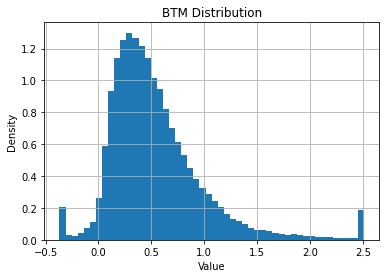

In [324]:
sent_df['btm'].hist(bins=50, density=True)
plt.title('BTM Distribution')
plt.xlabel('Value')
plt.ylabel('Density');

In [308]:
sent_df['btm'].quantile(np.linspace(0, 1, 3))

0.0   -0.368712
0.5    0.448472
1.0    2.508930
Name: btm, dtype: float64

In [310]:
sent_df['btm'].describe()

count    64774.000000
mean         0.540378
std          0.448557
min         -0.368712
25%          0.249911
50%          0.448472
75%          0.722177
max          2.508930
Name: btm, dtype: float64

In [317]:
sent_df['btm_q'] = pd.qcut(sent_df['btm'], q=3)
sent_df['btm_q'] = sent_df['btm_q'].astype(str)

In [531]:
df_panel['btm_q'] = pd.qcut(df_panel['btm'], q=3)
df_panel['btm_q'] = df_panel['btm_q'].astype(str)

In [320]:
sent_df['btm_q'].value_counts().sort_index()

(-0.37, 0.314]    21592
(0.314, 0.612]    21591
(0.612, 2.509]    21591
Name: btm_q, dtype: int64

In [325]:
btm_segments = set(sent_df['btm_q'])
len(btm_segments)

3

In [326]:
segment_results = {}

for seg in btm_segments:
    df_segment = sent_df[sent_df['btm_q'] == seg].copy()
    _, res_seg = fit_one_factor(df_segment, sentiment_features, control_variables)

    segment_results[seg] = res_seg

In [327]:
for k, v in segment_results.items():
    level0 = ['BTM ' + k] * len(level1) 
    v.columns = pd.MultiIndex.from_arrays([level0, level1])

In [328]:
segments_res_to_save = pd.concat([v for v in segment_results.values()], axis=1)
segments_res_to_save

BTM (0.314, 0.612]                       \
                                        coef      t     r2   pval   
tone                                0.005***  2.899  0.306  0.004   
tone_pos                               0.142  0.578  0.266  0.563   
tone_neg                           -0.253*** -2.635  0.303  0.008   
tone_harvard                            -0.0 -0.177  0.265   0.86   
tone_posharvard                      -0.064* -1.646  0.276    0.1   
tone_negharvard                       -0.027 -0.797  0.267  0.426   
rfpred_car01                         0.09***  2.814  0.337  0.005   
svrpred_car01                          0.003  0.465  0.266  0.642   
sldapred_car01                         -0.02 -0.316  0.265  0.752   
factorpred_car01                      0.001*  1.676  0.287  0.094   
positive_general                    0.018***  5.085  0.395    0.0   
negative_general                    -0.03*** -4.251  0.384    0.0   
polarity_general                    0.012***  4.927  0.402    0.0   
positive_revenue                       0.001  0.098  0.265  0.922   
negative_revenue                   -0.019*** -3.092  0.322  0.002   
polarity_revenue                     0.011**  2.382    0.3  0.017   
positive_profit                        0.009  0.916  0.269   0.36   
negative_profit                    -0.035*** -3.543  0.327    0.0   
polarity_profit                     0.033***  3.694  0.339    0.0   
positive_strategic_risk              0.005**  2.032  0.284  0.042   
negative_strategic_risk             -0.007** -2.472  0.299  0.013   
polarity_strategic_risk             0.004***  2.574  0.299   0.01   
positive_operational_risk            0.006**  2.301  0.292  0.021   
negative_operational_risk          -0.011*** -3.582  0.345    0.0   
polarity_operational_risk           0.006***  3.355  0.329  0.001   
positive_financial_risk               0.004*  1.652  0.281  0.099   
negative_financial_risk             -0.012**  -2.48  0.307  0.013   
polarity_financial_risk              0.004**  2.259  0.298  0.024   
positive_reputation_risk              0.009*  1.798  0.279  0.072   
negative_reputation_risk              -0.004  -1.43  0.274  0.153   
polarity_reputation_risk              0.004*  1.792   0.28  0.073   
positive_compliance_risk              0.005*  1.886  0.282  0.059   
negative_compliance_risk           -0.011*** -3.127  0.313  0.002   
polarity_compliance_risk            0.005***  2.758  0.302  0.006   

                          BTM (-0.37, 0.314]                       \
                                        coef      t     r2   pval   
tone                                  -0.003 -1.452  0.551  0.147   
tone_pos                             -0.461* -1.646  0.555    0.1   
tone_neg                               0.153  1.482  0.551  0.138   
tone_harvard                       -0.014*** -4.077  0.608    0.0   
tone_posharvard                       -0.023 -0.443  0.541  0.658   
tone_negharvard                     0.137***  3.633   0.59    0.0   
rfpred_car01                           0.028  0.864  0.547  0.388   
svrpred_car01                          0.011  1.395  0.555  0.163   
sldapred_car01                       0.155**  2.386  0.571  0.017   
factorpred_car01                       0.001   1.59  0.558  0.112   
positive_general                    0.023***  5.719  0.693    0.0   
negative_general                   -0.038*** -5.035  0.685    0.0   
polarity_general                    0.016***  5.657  0.702    0.0   
positive_revenue                       0.007   1.09  0.546  0.276   
negative_revenue                      -0.009 -1.385  0.551  0.166   
polarity_revenue                      0.009*  1.777  0.557  0.076   
positive_profit                       -0.005  -0.45  0.542  0.653   
negative_profit                        0.003  0.221  0.541  0.825   
polarity_profit                       -0.006 -0.571  0.542  0.568   
positive_strategic_risk             0.011***  3.693  0.592    0.0   
negative_strategic_risk

In [329]:
with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)
    panel_res_to_save.to_excel(writer, sheet_name='Panel one-factor regressions', index=True)
    industries_res_to_save.to_excel(writer, sheet_name='Industries regressions', index=True)
    segments_res_to_save.to_excel(writer, sheet_name='BTM segments', index=True)

## Volume

In [346]:
df_panel['log_volume'] = np.log(df_panel['volume'])
sent_df['log_volume'] = np.log(sent_df['volume'])

In [334]:
_, log_volume_res = fit_one_factor_panel(df_panel, 'log_volume', sentiment_features, control_variables, entity_effects=True, time_effects=True)

100%|██████████| 34/34 [00:28<00:00,  1.19it/s]


In [335]:
log_volume_res

,coef,t,r2,pval
tone,-0.443***,-21.719,55.299,0.0
tone_pos,-23.0***,-8.771,54.981,0.0
tone_neg,29.644***,27.304,55.516,0.0
tone_harvard,-0.166***,-5.2,54.94,0.0
tone_posharvard,-2.822***,-4.843,54.937,0.0
tone_negharvard,1.124***,2.911,54.925,0.004
rfpred_car01,-1.057***,-7.364,54.962,0.0
svrpred_car01,-0.032,-0.94,54.919,0.347
sldapred_car01,-5.037***,-13.308,55.062,0.0
factorpred_car01,-0.016***,-7.356,54.962,0.0


In [338]:
# _, volume_res = fit_one_factor_panel(df_panel, 'volume', sentiment_features, control_variables, entity_effects=True, time_effects=True)

In [339]:
# volume_res

In [347]:
_, log_volume_res_ = fit_one_factor(sent_df, sentiment_features, control_variables, 'log_volume')

In [350]:
# log_volume_res_

In [351]:
level0 = ['Volume'] * len(level1)
log_volume_res.columns = pd.MultiIndex.from_arrays([level0, level1])

In [353]:
with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    res_to_save.to_excel(writer, sheet_name='Replicate Frankel', index=True)
    panel_res_to_save.to_excel(writer, sheet_name='Panel one-factor regressions', index=True)
    industries_res_to_save.to_excel(writer, sheet_name='Industries regressions', index=True)
    segments_res_to_save.to_excel(writer, sheet_name='BTM segments', index=True)
    log_volume_res.to_excel(writer, sheet_name='Log Volume regressions', index=True)

## RF

In [379]:
Xrf = sent_df[sentiment_features + control_variables].copy()
Yres = sent_df[target].copy()
# Yres

In [382]:
random_grid = {
    'n_estimators': [100, 150, 200],
    'max_features': ['sqrt',],
    'max_depth': [3, 4, 5],
    'min_samples_split': [28, 29, 30, 31, 32,],
    'min_samples_leaf': [11, 12, 13, 14, 15],
    'bootstrap': [True]
    }

In [384]:
rf_random_res = RandomizedSearchCV(estimator=rf_llama_res,
                               param_distributions=random_grid,
                               n_iter=200, cv=5, verbose=4, random_state=108, n_jobs=mp.cpu_count())

In [385]:
rf_random_res

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(max_depth=5,
                                                   max_features='sqrt',
                                                   min_samples_leaf=9,
                                                   min_samples_split=29,
                                                   n_estimators=150,
                                                   oob_score=True,
                                                   random_state=108),
                   n_iter=200, n_jobs=152,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [3, 4, 5],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [11, 12, 13, 14,
                                                             15],
                                        'min_samples_split': [28, 29, 30, 31,
                                  

In [386]:
rf_random_res.fit(Xrf, Yres)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(max_depth=5,
                                                   max_features='sqrt',
                                                   min_samples_leaf=9,
                                                   min_samples_split=29,
                                                   n_estimators=150,
                                                   oob_score=True,
                                                   random_state=108),
                   n_iter=200, n_jobs=152,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [3, 4, 5],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [11, 12, 13, 14,
                                                             15],
                                        'min_samples_split': [28, 29, 30, 31,
                                  

In [387]:
print(f'Best Parameters: {rf_random_res.best_params_} \n')

Best Parameters: {'n_estimators': 200, 'min_samples_split': 28, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': True} 



In [398]:
rf_hyper.update(rf_random_res.best_params_)
print(f'Current Hyperparams: {rf_hyper} \n')

rf_llama_res = RandomForestRegressor(**rf_hyper)
rf_llama_res.fit(Xrf,Yres)
# print(rf_llama_res.feature_names_in_)

Current Hyperparams: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 28, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'bootstrap': True, 'oob_score': True, 'random_state': 108} 



RandomForestRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=13,
                      min_samples_split=28, n_estimators=200, oob_score=True,
                      random_state=108)

In [415]:
rf_llama_res.feature_names_in_[[3, 2, 1]]

array(['tone_harvard', 'tone_neg', 'tone_pos'], dtype=object)

In [471]:
rf_llama_res.oob_score_

0.0068191121874559

In [423]:
def plot_feature_importance(model, names, threshold=None, kind="impurity", data=None, path=None):

    if kind=="impurity":
        feature_importance_df = pd.DataFrame.from_dict({'feature_importance': model.feature_importances_,
                                                        'Feature': model.feature_names_in_})\
        .set_index('Feature').sort_values('feature_importance', ascending=True)
        
        if threshold is not None:
            feature_importance_df = feature_importance_df[feature_importance_df.feature_importance > threshold]

        plt.clf();
        feature_importance_df.plot.bar(color='orange', align='center', legend=None)
        plt.xlabel(None)
        plt.title('Feature Importances')
        plt.ylabel('Average Impurity Decrease')
        plt.xticks(rotation=30, ha='right');


    elif kind=="permutation":
        if not data:
            print("data arg mandatory for permutation feature importance")
            return None

        result = permutation_importance(model, data['X'], data['Y'], n_repeats=30, random_state=108, n_jobs=2)

        sorted_importances_idx = result.importances_mean.argsort()
        importances = pd.DataFrame(
            result.importances[sorted_importances_idx].T,
            columns=[data['X_labels'][c] for c in data['X'].columns[sorted_importances_idx]],
        )
        ax = importances.plot.box(vert=False, whis=10)
        ax.set_title("Permutation Importances")
        ax.axvline(x=0, color="k", linestyle="--")
        ax.set_xlabel("Decrease in accuracy score")
        ax.figure.tight_layout()

    elif kind=="both":
        feature_importance_df = pd.DataFrame.from_dict({'feature_importance': model.feature_importances_,
                                                        'Feature': model.feature_names_in_})\
        .set_index('Feature').sort_values('feature_importance', ascending=True)
        
        if threshold is not None:
            feature_importance_df = feature_importance_df[feature_importance_df.feature_importance > threshold]

        if not data:
            print("data arg mandatory for permutation feature importance")
            return None

        perm_result = permutation_importance(model, data['X'], data['Y'], n_repeats=30, random_state=108, n_jobs=8)
#         print(perm_result)

        sorted_importances_idx = perm_result.importances_mean.argsort()
        perm_importances = pd.DataFrame(
            perm_result.importances[sorted_importances_idx].T,
            columns=model.feature_names_in_[sorted_importances_idx],
        )

        plt.clf();
        sns.set(style="ticks")
        figure, (ax1,ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=False, sharex=False, squeeze=True,)

        feature_importance_df.plot.bar(color='lightblue', align='center', legend=None, ax=ax1, edgecolor='black')
        ax1.set_xlabel('')
        ax1.set_title('Feature Importances')
        ax1.grid()
        ax1.set_ylabel('Average Impurity Decrease')

        perm_importances.plot.box(vert=True, whis=10, ax=ax2)
        ax2.set_title("Permutation Importances")
        ax2.axhline(y=0, color="k", linestyle="--")
        ax2.set_ylabel("Decrease in MSE")
        ax2.grid()
        ax2.tick_params(axis='x', labelrotation=90)

        if path:
#             path = join(tables_path, path)
            plt.savefig(path, bbox_inches='tight');
            plt.show();

<Figure size 432x288 with 0 Axes>

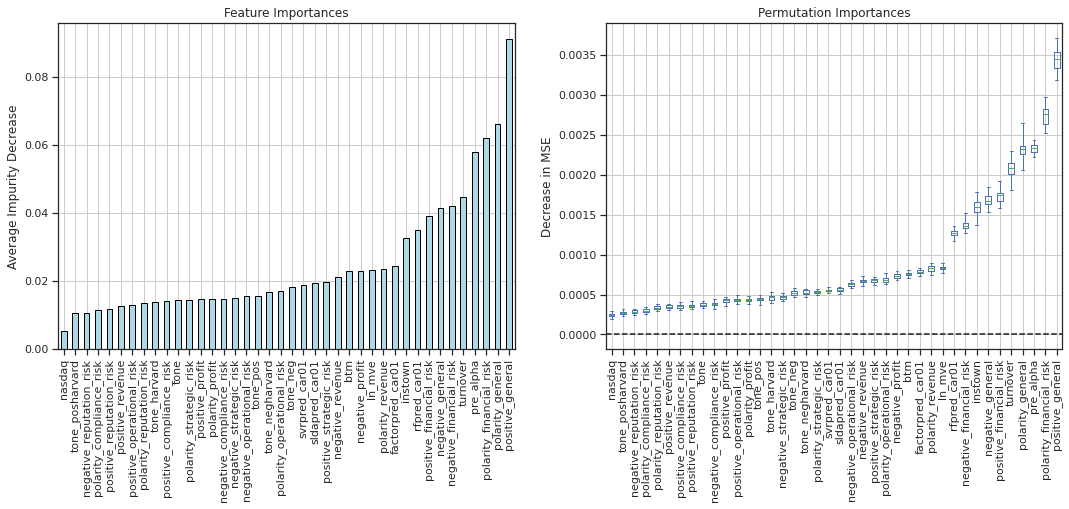

In [424]:
plot_feature_importance(rf_llama_res, rf_llama_res.feature_names_in_,
                        kind="both", data=dict(X=Xrf, Y=Yres), path='figures/random_forest_importance.png')

In [437]:
def plot_partial_dependence(estimator,
                            X,
                            feature=0,
#                             categorical_features=[True]*8+[False]*2,
                            figsize=(5, 5),
                            X_labels=None,
                            path=None,
                            rotation=25,
                            ols=None,
                            pt=(0.1,0.9),
                            axs=None):
    """
    Plot partial dependence for features
    """

    plt.clf();
    if not axs:
        fig, axs = plt.subplots(figsize=figsize);
    #     pdd_opts = dict(response_method="predict_proba", kind='average', n_jobs=-1, method='brute')
    pdd_opts = dict(response_method="predict", kind='average', n_jobs=-1, method='brute')

    X_labels = [X_labels[c] for c in X.columns] if X_labels else X.columns.tolist()

    pdd = PartialDependenceDisplay.from_estimator(estimator=estimator,
                                                    X=X,
                                                    features=[feature],
                                                    feature_names=X_labels,
                                                    percentiles=pt,
#                                                         categorical_features=categorical_features,
                                                    **pdd_opts,ax=axs);
    try:
        pdd.axes_[0,0].set_ylabel("Average Response Probability");
        pdd.axes_[0,0].set_xlabel(X_labels[feature]);
        pdd.axes_[0,0].set_yticks(np.arange(0.2, 0.85, 0.1));
        pdd.axes_[0,0].tick_params(axis='x', labelrotation=rotation,labelsize=11);
        pdd.axes_[0,0].tick_params(axis='y', labelsize=11);

        labels = cat[X.columns[feature]]
        pdd.axes_[0,0].set_xticks(list(range(len(labels))), labels=labels);
        for c in range(len(labels)):
            pdd.axes_[0,0].get_children()[c].set_color((0.8,0.5,0,0.5));

    except:
        print(f"Continuous feature")
        perc = np.percentile(X[X.columns[feature]],pt)
#         xs = np.linspace(perc[0],perc[1],10)
#         ys = ols_mx(ols['result'], X.columns[feature], xs, res_df, ols['formula'])
        pdd.axes_[0,0].get_children()[0].set_label('RF')
#         pdd.axes_[0,0].plot(xs, ys, 'g--', linewidth=.75, label='OLS')
        pdd.axes_[0,0].legend(loc='upper left')


    if path:
#         path = join(tables_path, path)
        plt.savefig(path, bbox_inches="tight");
        plt.show();
    return pdd


In [455]:
sample = Xrf.sample(n=10_000, random_state=108)
sample.shape

(10000, 40)

In [456]:
# name = 'polarity_general'

# plot_partial_dependence(estimator=rf_llama_res,
#                         X=sample,
#                         feature=name,
#                         X_labels=None,
#                         figsize=(6, 5), rotation=0, path=None,
#                         ols=None)

In [444]:
sample.head(2)

,tone,tone_pos,tone_neg,tone_harvard,tone_posharvard,tone_negharvard,rfpred_car01,svrpred_car01,sldapred_car01,factorpred_car01,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk,ln_mve,btm,turnover,pre_alpha,instown,nasdaq
13169,-0.128205,0.004600,0.005953,0.215980,0.043925,0.028321,-0.002070,-0.006763,-0.002266,-0.510253,0.197678,0.106785,0.090893,0.166107,0.113708,0.052399,0.216934,0.096146,0.120789,0.112671,0.368340,-0.255669,0.088364,0.385834,-0.297470,0.151802,0.351883,-0.200081,0.046898,0.363201,-0.316303,0.151405,0.349594,-0.198189,4.789323,0.193553,4.563250,-0.001870,0.276729,1.0
30833,-0.505426,0.004517,0.013750,0.101628,0.059405,0.048444,0.006121,0.018980,-0.002019,0.268987,0.081177,0.242418,-0.161242,0.178711,0.134033,0.044678,0.174927,0.095657,0.079269,0.132965,0.256329,-0.123363,0.112503,0.254955,-0.142452,0.110588,0.241581,-0.130993,0.095928,0.240871,-0.144943,0.147388,0.213326,-0.065937,7.886634,0.766056,4.453114,-0.000265,1.000000,1.0


In [457]:
features_to_analyse = ['tone', 'rfpred_car01', 'factorpred_car01',
                       'polarity_general', 'positive_general', 'negative_general',
                       'polarity_financial_risk', 'polarity_profit', 'polarity_revenue']
features_indices = list(np.argwhere(sample.columns.isin(features_to_analyse)).ravel())
features_indices

[0, 6, 9, 10, 11, 12, 15, 18, 27]

In [458]:
# sample = sample[features_to_analyse].reset_index(drop=True)

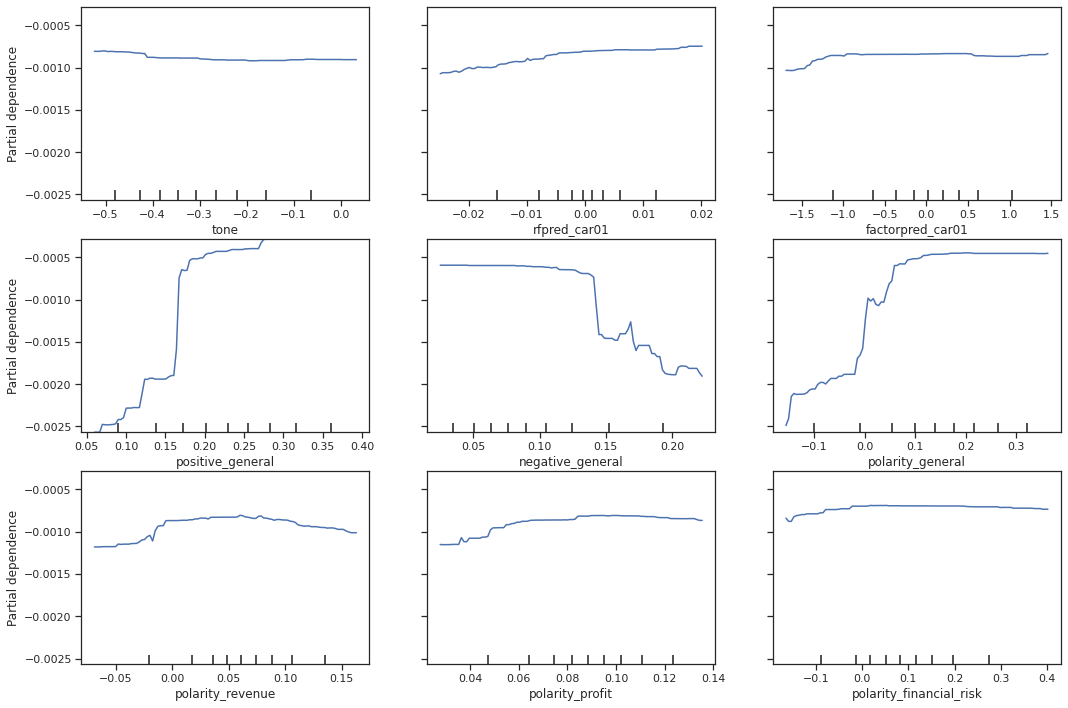

In [480]:
fig, ax = plt.subplots(figsize=(15, 10))


PartialDependenceDisplay.from_estimator(
    rf_llama_res, 
    sample,
    features=features_indices,
    feature_names=sample.columns,
    ax=ax,
#     grid_resolution=50
)

plt.tight_layout()
# plt.tight_layout(pad=3.0)
ax.grid(True, which='both', alpha=0.4, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# ax.minorticks_on()
# ax.grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=0.5)

plt.savefig('figures/pdp_all_sentiments.png')
plt.show()

## Interaction term

In [484]:
sent_df['intercation_term'] = sent_df['polarity_general'] * sent_df['btm']

In [528]:
df_panel['intercation_term'] = df_panel['polarity_general'] * df_panel['btm']

In [532]:
# df_panel['btm_q']

In [533]:
# sentiment_features

In [544]:
segment_results = {}
segment_models = {}

for seg in btm_segments:
    df_segment = sent_df[sent_df['btm_q'] == seg].copy()
    model_seg, res_seg = fit_one_factor(df_segment, ['polarity_general'], control_variables + ['intercation_term'])
    segment_models[seg] = model_seg
    segment_results[seg] = res_seg

In [545]:
for k, v in segment_results.items():
    level0 = ['BTM ' + k] * len(level1) 
    v.columns = pd.MultiIndex.from_arrays([level0, level1])

In [546]:
interaction_term = pd.concat([v for v in segment_results.values()], axis=1)
interaction_term

BTM (0.314, 0.612]                      BTM (-0.37, 0.314]  \
                               coef      t     r2   pval               coef   
polarity_general              0.019  1.385  0.399  0.166           0.015***   

                                   BTM (0.612, 2.509]                       
                     t     r2 pval               coef      t     r2   pval  
polarity_general  3.66  0.699  0.0             0.014*  1.821  0.522  0.069

In [547]:
x = segment_models['(-0.37, 0.314]']['polarity_general']['model']

In [548]:
print(x.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     16.22
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           6.51e-24
Time:                        18:01:31   Log-Likelihood:                 33236.
No. Observations:               21592   AIC:                        -6.645e+04
Df Residuals:                   21583   BIC:                        -6.638e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0019      0.002  

In [549]:
x = segment_models['(0.314, 0.612]']['polarity_general']['model']

In [550]:
print(x.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     8.101
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           6.09e-11
Time:                        18:01:42   Log-Likelihood:                 36765.
No. Observations:               21591   AIC:                        -7.351e+04
Df Residuals:                   21582   BIC:                        -7.344e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0023      0.004  

In [524]:
x = segment_models['(0.612, 2.509]']['polarity_general']['model']

In [525]:
print(x.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     11.37
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           4.06e-16
Time:                        17:52:55   Log-Likelihood:                 33516.
No. Observations:               21591   AIC:                        -6.701e+04
Df Residuals:                   21582   BIC:                        -6.694e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0003      0.002  

In [527]:
df_panel

datadate  prcc_f     csho       ceq   instown   permco  \
gvkey     year                                                               
b'001004' 2002.0  2002-05-31   11.44   31.870   310.235  0.903180  20000.0   
          2003.0  2003-05-31    4.50   31.851   294.988  0.900913  20000.0   
          2004.0  2004-05-31    9.58   32.245   301.684  0.901062  20000.0   
          2005.0  2005-05-31   16.04   32.586   314.744  1.000000  20000.0   
          2006.0  2006-05-31   24.08   36.654   422.717  1.000000  20000.0   
...                      ...     ...      ...       ...       ...      ...   
b'317264' 2017.0  2017-03-31   10.53   54.975   976.002  0.000000  54852.0   
          2018.0  2018-03-31    7.49   55.090   959.413  0.565377  54852.0   
          2019.0  2019-03-31    6.42   55.168   912.683  0.529435  54852.0   
b'318728' 2018.0  2017-12-31   51.71  199.853  9208.000  0.000000  55804.0   
          2019.0  2018-12-31   39.83  197.100  8276.000  0.722051  55804.0   

                   permno  date_filed                         filename  \
gvkey     year                                                           
b'001004' 2002.0  54594.0  2002-08-26     b'1750_0000912057-02-033450'   
          2003.0  54594.0  2003-08-18     b'1750_0001047469-03-028005'   
          2004.0  54594.0  2004-07-22     b'1750_0001047469-04-023905'   
          2005.0  54594.0  2005-07-22     b'1750_0001104659-05-033688'   
          2006.0  54594.0  2006-07-17     b'1750_0001104659-06-047248'   
...                   ...         ...                              ...   
b'317264' 2017.0  14642.0  2017-06-14  b'1596993_0001596993-17-000010'   
          2018.0  14642.0  2018-06-28  b'1596993_0001596993-18-000015'   
          2019.0  14642.0  2019-05-30  b'1596993_0001596993-19-000010'   
b'318728' 2018.0  16496.0  2018-02-26  b'1527469_0001527469-18-000011'   
          2019.0  16496.0  2019-02-27  b'1527469_0001527469-19-000007'   

                          mve       btm       volume    SHROUT  turnover  \
gvkey     year                                                             
b'001004' 2002.0    364.59280  0.850908   32389900.0   26860.0  1.205879   
          2003.0    143.32950  2.058111   21138500.0   31850.0  0.663689   
          2004.0    308.90710  0.976617   41549083.0   32245.0  1.288543   
          2005.0    522.67944  0.602174   47055900.0   32438.0  1.450641   
          2006.0    882.62832  0.478930   97373000.0   36461.0  2.670607   
...                       ...       ...          ...       ...       ...   
b'317264' 2017.0    578.88675  1.685998   59346255.0   54967.0  1.079671   
          2018.0    412.62410  2.325150   58762972.0   55107.0  1.066343   
          2019.0    354.17856  2.508930   40707109.0   55167.0  0.737889   
b'318728' 2018.0  10334.39863  0.891005  334320819.0  142348.0  2.348616   
          2019.0   7850.49300  1.054201  338861633.0  164849.0  2.055588   

                  pre_alpha  nasdaq     car01  tone_pos  tone_neg      tone  \
gvkey     year                                                                
b'001004' 2002.0  -0.002825     0.0 -0.001721  0.004142  0.007198 -0.269461   
          2003.0  -0.000024     0.0  0.144115  0.003915  0.007516 -0.315068   
          2004.0   0.000483     0.0 -0.050975  0.004134  0.007463 -0.287037   
          2005.0   0.001064     0.0 -0.003768  0.004717  0.007433 -0.223529   
          2006.0   0.001258     0.0  0.000631  0.005518  0.009995 -0.288557   
...                     ...     ...       ...       ...       ...       ...   
b'317264' 2017.0  -0.000467     0.0 -0.029018  0.005495  0.014015 -0.436735   
          2018.0  -0.000395     0.0 -0.047430  0.005525  0.014667 -0.452713   
          2019.0   0.000974     0.0 -0.027795  0.005649  0.013585 -0.412628   
b'318728' 2018.0  -0.000431     0.0 -0.001046  0.007346  0.013908 -0.308759   
          2019.0  -0.000151     0.0  0.006164  0.007526  0.013676 -0.290089   

                  tone_po

In [551]:
# segment_results = {}
# segment_models = {}

# for seg in btm_segments:
#     df_panel_seg = df_panel[df_panel['btm_q'] == seg].copy()
# #     model_seg, res_seg = fit_one_factor(df_segment, ['polarity_general'], control_variables + ['intercation_term'])

#     model_seg, res_seg = fit_one_factor_panel(df_panel_seg, target, ['polarity_general'],
#                                               control_variables + ['intercation_term'],
#                                               entity_effects=True, time_effects=True)
#     segment_models[seg] = model_seg
#     segment_results[seg] = res_seg

In [552]:
# for k, v in segment_results.items():
#     level0 = ['BTM ' + k] * len(level1) 
#     v.columns = pd.MultiIndex.from_arrays([level0, level1])

In [553]:
# interaction_term = pd.concat([v for v in segment_results.values()], axis=1)
# interaction_term

In [542]:
# x = segment_models['(-0.37, 0.314]']['polarity_general']['model']
# print(x)

In [543]:
# x = segment_models['(0.612, 2.509]']['polarity_general']['model']
# print(x)

In [ ]:
def ols_with_cluster(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results

In [567]:
# df_panel.head()

In [605]:
formula = f"{target} ~ polarity_general + ln_mve + btm + turnover + pre_alpha + instown + nasdaq + polarity_general*btm"

model = PanelOLS.from_formula(formula, df_panel, drop_absorbed=True)
results = model.fit()

In [606]:
print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  car01   R-squared:                        0.0062
Estimator:                   PanelOLS   R-squared (Between):              0.0237
No. Observations:               64774   R-squared (Within):               0.0021
Date:                Thu, Nov 27 2025   R-squared (Overall):              0.0062
Time:                        19:18:48   Log-likelihood                 1.032e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      50.738
Entities:                        9283   P-value                           0.0000
Avg Obs:                       6.9777   Distribution:                 F(8,64766)
Min Obs:                       1.0000                                           
Max Obs:                       25.000   F-statistic (robust):             50.738
                            

In [607]:
formula = f"{target} ~ polarity_general + ln_mve + btm + turnover + pre_alpha + instown + nasdaq + polarity_general*btm"
model = OLS.from_formula(formula, sent_df, drop_absorbed=True)
model = model.fit()

results = model.get_robustcov_results(cov_type='cluster', groups=sent_df['gvkey'])

In [608]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     33.57
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           1.22e-52
Time:                        19:18:58   Log-Likelihood:             1.0317e+05
No. Observations:               64774   AIC:                        -2.063e+05
Df Residuals:                   64765   BIC:                        -2.062e+05
Df Model:                           8                                         
Covariance Type:              cluster                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0010 

In [588]:
control_variables

['ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']

In [616]:
formula = f"{target} ~ TimeEffects + polarity_general + ln_mve + btm + turnover + pre_alpha + instown + nasdaq + polarity_general*ln_mve"

model = PanelOLS.from_formula(formula, df_panel, drop_absorbed=True)
results = model.fit()

In [617]:
print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  car01   R-squared:                        0.0059
Estimator:                   PanelOLS   R-squared (Between):              0.0100
No. Observations:               64774   R-squared (Within):               0.0018
Date:                Thu, Nov 27 2025   R-squared (Overall):              0.0027
Time:                        21:05:01   Log-likelihood                 1.032e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      47.727
Entities:                        9283   P-value                           0.0000
Avg Obs:                       6.9777   Distribution:                 F(8,64742)
Min Obs:                       1.0000                                           
Max Obs:                       25.000   F-statistic (robust):             47.727
                            

In [598]:
formula = f"{target} ~ polarity_general + ln_mve + btm + turnover + pre_alpha + instown + nasdaq + polarity_general*ln_mve"
model = OLS.from_formula(formula, sent_df, drop_absorbed=True)
model = model.fit()

results = model.get_robustcov_results(cov_type='cluster', groups=sent_df['gvkey'])
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     34.16
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           1.31e-53
Time:                        19:17:48   Log-Likelihood:             1.0317e+05
No. Observations:               64774   AIC:                        -2.063e+05
Df Residuals:                   64765   BIC:                        -2.062e+05
Df Model:                           8                                         
Covariance Type:              cluster                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

<AxesSubplot:>

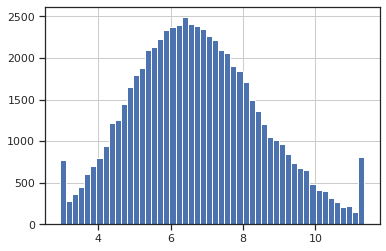

In [593]:
sent_df['ln_mve'].hist(bins=50)

<AxesSubplot:>

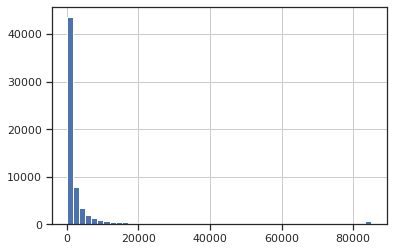

In [594]:
sent_df['mve'].hist(bins=50)

## Multivariate regressions

In [445]:
sentiment_features

['tone',
 'tone_pos',
 'tone_neg',
 'tone_harvard',
 'tone_posharvard',
 'tone_negharvard',
 'rfpred_car01',
 'svrpred_car01',
 'sldapred_car01',
 'factorpred_car01',
 'polarity_general',
 'polarity_revenue',
 'polarity_profit',
 'polarity_strategic_risk',
 'polarity_operational_risk',
 'polarity_financial_risk',
 'polarity_reputation_risk',
 'polarity_compliance_risk']

In [456]:
results = ols_with_cluster(df_, 'car01', lm_tone + frankel_variables + llama + control_variables, 'gvkey')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     13.32
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.12e-46
Time:                        14:26:46   Log-Likelihood:                 89278.
No. Observations:               55899   AIC:                        -1.785e+05
Df Residuals:                   55877   BIC:                        -1.783e+05
Df Model:                          21                                         
Covariance Type:              cluster                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [709]:
# lm_tone + harv_tone + frankel_variables + llama
results = ols_with_cluster(df_, 'car01', lm_tone + control_variables, 'gvkey')
# print(color.BOLD + 'LM')
print('LM')
print(results.summary())

LM
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     19.52
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           9.27e-33
Time:                        14:54:47   Log-Likelihood:                 89208.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55889   BIC:                        -1.783e+05
Df Model:                           9                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0027      0.002      1.435      

In [653]:
# print('LM RMSE', round(np.sqrt(results.mse_resid), 5))

X = add_constant(df_[lm_tone + control_variables])
y_pred = results.predict(X)

lm_dict = {}
lm_dict['rmse'] = np.sqrt(results.mse_resid)
lm_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
lm_dict['r2_adj'] = results.rsquared_adj
lm_dict
                         
# print('LM RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('LM MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('LM R2', round(results.rsquared_adj, 4))

{'rmse': 0.04905884158643665,
 'mae': 0.17900772052741823,
 'r2_adj': 0.004348924996459669}

In [711]:
results_fr = ols_with_cluster(df_, 'car01', frankel_variables + control_variables, 'gvkey')
print('Frankel')
print(results_fr.summary())

Frankel
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     18.36
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           1.05e-33
Time:                        14:54:59   Log-Likelihood:                 89217.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55888   BIC:                        -1.783e+05
Df Model:                          10                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0011     

In [657]:
print('Frankel RMSE', round(np.sqrt(results_fr.mse_resid), 5))

X = add_constant(df_[frankel_variables + control_variables])
y_pred = results_fr.predict(X)
# print('Frankel RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('Frankel MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('Frankel R2', round(results_fr.rsquared_adj, 4))

fr_dict = {}
fr_dict['rmse'] = np.sqrt(results_fr.mse_resid)
fr_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
fr_dict['r2_adj'] = results_fr.rsquared_adj
fr_dict

Frankel RMSE 0.04905


{'rmse': 0.04905156593933803,
 'mae': 0.1789713154635392,
 'r2_adj': 0.004644222172728307}

In [746]:
llama = ['polarity_general',
 'polarity_revenue',
 'polarity_profit',
 'polarity_strategic_risk',
 'polarity_operational_risk',
 'polarity_financial_risk',
 'polarity_reputation_risk',
 'polarity_compliance_risk']

# llama = ['polarity_general', 'polarity_profit', 'polarity_financial_risk',]

In [748]:
results_llama = ols_with_cluster(df_, 'car01', llama + control_variables, 'gvkey')
print('Llama')
print(results_llama.summary())

Llama
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     18.07
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.77e-45
Time:                        16:23:16   Log-Likelihood:                 89265.
No. Observations:               55899   AIC:                        -1.785e+05
Df Residuals:                   55884   BIC:                        -1.784e+05
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const           

In [750]:
# print('Llama RMSE', round(np.sqrt(results_llama.mse_resid), 6))

X = add_constant(df_[llama + control_variables])
y_pred = results_llama.predict(X)
# print('Llama RMSE', round(np.sqrt(mean_squared_error(df_['car01'], y_pred)), 5))
# print('Llama MAE', round(np.sqrt(mean_absolute_error(df_['car01'], y_pred)), 5))
# print('Llama R2', round(results_llama.rsquared_adj, 4))

llama_dict = {}
llama_dict['rmse'] = np.sqrt(mean_squared_error(df_['car01'], y_pred))
llama_dict['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
llama_dict['r2_adj'] = results_llama.rsquared_adj
llama_dict

{'rmse': 0.04900522712386684,
 'mae': 0.1789388649652172,
 'r2_adj': 0.006257288975319519}

In [752]:
lm_df = pd.DataFrame.from_dict(lm_dict, orient='index')
lm_df.columns = ['LM']

fr_df = pd.DataFrame.from_dict(fr_dict, orient='index')
fr_df.columns = ['Frankel']

llama_df = pd.DataFrame.from_dict(llama_dict, orient='index')
llama_df.columns = ['Llama']

res_df = pd.concat([lm_df, fr_df, llama_df], axis=1)
round(res_df, 4)

,LM,Frankel,Llama
rmse,0.0491,0.0491,0.0490
mae,0.1790,0.1790,0.1789
r2_adj,0.0043,0.0046,0.0063


### Without control

In [770]:
results = ols_with_cluster(df_, 'car01', lm_tone, 'gvkey')
# print(color.BOLD + 'LM')
print('LM')
print(results.summary())

LM
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.719
Date:                Tue, 21 Oct 2025   Prob (F-statistic):            0.00271
Time:                        16:25:09   Log-Likelihood:                 89088.
No. Observations:               55899   AIC:                        -1.782e+05
Df Residuals:                   55895   BIC:                        -1.781e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0037      0.002      2.400      

In [772]:
X = add_constant(df_[lm_tone])
y_pred = results.predict(X)

lm_dict2 = {}
lm_dict2['rmse'] = np.sqrt(results.mse_resid)
lm_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
lm_dict2['r2_adj'] = results.rsquared_adj
# lm_dict2

In [774]:
results_fr = ols_with_cluster(df_, 'car01', frankel_variables, 'gvkey')
print('Frankel')
print(results_fr.summary())

Frankel
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.37
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.37e-09
Time:                        16:25:16   Log-Likelihood:                 89116.
No. Observations:               55899   AIC:                        -1.782e+05
Df Residuals:                   55894   BIC:                        -1.782e+05
Df Model:                           4                                         
Covariance Type:              cluster                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0007     

In [776]:
X = add_constant(df_[frankel_variables])
y_pred = results_fr.predict(X)
fr_dict2 = {}
fr_dict2['rmse'] = np.sqrt(results_fr.mse_resid)
fr_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
fr_dict2['r2_adj'] = results_fr.rsquared_adj
fr_dict2

{'rmse': 0.049138229412405136,
 'mae': 0.17906464890022694,
 'r2_adj': 0.0011239598033245812}

In [778]:
llama = ['polarity_general', 'polarity_profit', 'polarity_financial_risk',]

results_llama = ols_with_cluster(df_, 'car01', llama, 'gvkey')
print('Llama')
print(results_llama.summary())

Llama
                            OLS Regression Results                            
Dep. Variable:                  car01   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     53.16
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           4.92e-34
Time:                        16:25:21   Log-Likelihood:                 89192.
No. Observations:               55899   AIC:                        -1.784e+05
Df Residuals:                   55895   BIC:                        -1.783e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const               

In [780]:
X = add_constant(df_[llama])
y_pred = results_llama.predict(X)

llama_dict2 = {}
llama_dict2['rmse'] = np.sqrt(mean_squared_error(df_['car01'], y_pred))
llama_dict2['mae'] = np.sqrt(mean_absolute_error(df_['car01'], y_pred))
llama_dict2['r2_adj'] = results_llama.rsquared_adj
llama_dict2

{'rmse': 0.049068739149443694,
 'mae': 0.17898868362969753,
 'r2_adj': 0.003875861344565412}

In [782]:
# without control
lm_df2 = pd.DataFrame.from_dict(lm_dict2, orient='index')
lm_df2.columns = ['LM']

fr_df2 = pd.DataFrame.from_dict(fr_dict2, orient='index')
fr_df2.columns = ['Frankel']

llama_df2 = pd.DataFrame.from_dict(llama_dict2, orient='index')
llama_df2.columns = ['Llama']

res_df2 = pd.concat([lm_df2, fr_df2, llama_df2], axis=1)
round(res_df2, 4)

,LM,Frankel,Llama
rmse,0.0492,0.0491,0.0491
mae,0.1791,0.1791,0.1790
r2_adj,0.0002,0.0011,0.0039


In [768]:
# with control
round(res_df, 4)

,LM,Frankel,Llama
rmse,0.0491,0.0491,0.0490
mae,0.1790,0.1790,0.1789
r2_adj,0.0043,0.0046,0.0063


In [ ]:
# fixed effects 
subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)

## Figure 1
Filing Returns and Sentiment

In [233]:
sent_df_ = sent_df.copy()

In [234]:
quantile_feats = ['rfpred_car01', 'tone', 'tone_harvard', 'polarity_general', 'polarity_financial_risk', 'polarity_revenue']

for f in quantile_feats:
    sent_df_[f'{f}_quintile'] = pd.qcut(sent_df_[f], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')

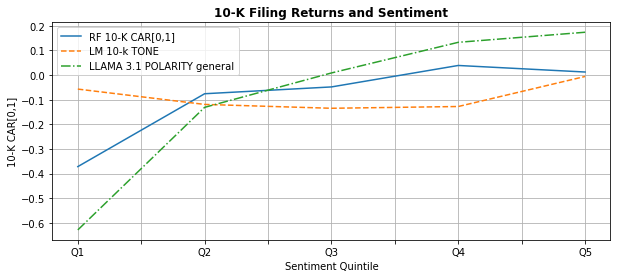

In [238]:
plt.figure(figsize=(10, 4))
plt.title('10-K Filing Returns and Sentiment', weight='bold')
(100*sent_df_.groupby(['rfpred_car01_quintile'])[target].mean()).plot(label='RF 10-K CAR[0,1]')
(100*sent_df_.groupby(['tone_quintile'])[target].mean()).plot(label='LM 10-k TONE', style='--')
# (100*df_.groupby(['tone_harvard_quintile'])[target].mean()).plot(label='HARV 10-K TONE', style=':')
(100*sent_df_.groupby(['polarity_general_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY general', style='-.')
# (100*sent_df_.groupby(['polarity_financial_risk_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY fin risk', style='-.')
# (100*df_.groupby(['polarity_revenue_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY revenue', style='-.')
plt.ylabel('10-K CAR[0,1]')
plt.xlabel('Sentiment Quintile')
plt.grid()
plt.legend();

In [239]:
quantile_feats = ['rfpred_car01', 'tone', 'tone_harvard', 'polarity_general', 'polarity_financial_risk', 'polarity_revenue']

for f in quantile_feats:
    sent_df_[f'{f}_quintile'] = pd.qcut(sent_df_[f], q=10,  duplicates='drop')

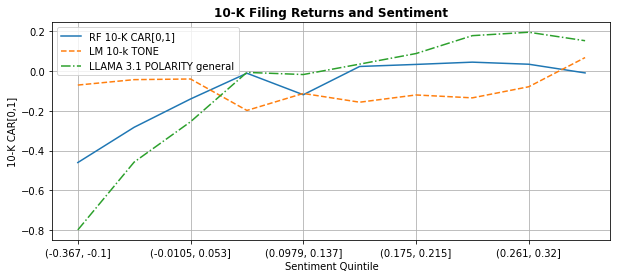

In [241]:
plt.figure(figsize=(10, 4))
plt.title('10-K Filing Returns and Sentiment', weight='bold')
(100*sent_df_.groupby(['rfpred_car01_quintile'])[target].mean()).plot(label='RF 10-K CAR[0,1]')
(100*sent_df_.groupby(['tone_quintile'])[target].mean()).plot(label='LM 10-k TONE', style='--')
# (100*df_.groupby(['tone_harvard_quintile'])[target].mean()).plot(label='HARV 10-K TONE', style=':')
(100*sent_df_.groupby(['polarity_general_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY general', style='-.')
# (100*df_.groupby(['polarity_financial_risk_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY fin risk', style='-.')
# (100*df_.groupby(['polarity_revenue_quintile'])[target].mean()).plot(label='LLAMA 3.1 POLARITY revenue', style='-.')
plt.ylabel('10-K CAR[0,1]')
plt.xlabel('Sentiment Quintile')
plt.grid()
plt.legend();

In [388]:
df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE
0,b'001004',1996-05-31,22.124999,15.998,204.635,0.769911,20000.0,54594.0,1996-08-20,b'1750_0000912057-96-018355',353.955727,0.578137,8818300.0,16025.0,0.550284,0.000422,0.0,-0.004494,0.007245,0.006079,0.087500,0.052049,0.028065,0.299376,0.005316,0.031102,0.000190,1996.0,5.869172,0.661720,0000912057-96-018355,1750,19960820
1,b'001004',1997-05-31,30.999985,18.204,269.259,0.832853,20000.0,54594.0,1997-08-22,b'1750_0000912057-97-028915',564.323722,0.477136,21456200.0,18156.0,1.181769,0.001376,0.0,0.005077,0.006206,0.004227,0.189655,0.053872,0.025992,0.349099,0.000997,-0.008040,0.000435,1997.0,6.335628,-0.175370,0000912057-97-028915,1750,19970822
2,b'001004',1998-05-31,26.437500,27.704,300.850,0.893793,20000.0,54594.0,1998-08-20,b'1750_0001047469-98-032283',732.424500,0.410759,18200800.0,27690.0,0.657306,0.000424,0.0,0.025747,0.005877,0.003495,0.287129,0.050854,0.022802,0.380851,0.002169,0.024143,-0.000279,1998.0,6.596360,0.229395,0001047469-98-032283,1750,19980820
3,b'001004',1999-05-31,19.750000,27.381,326.035,0.804165,20000.0,54594.0,1999-08-18,b'1750_0001047469-99-032978',540.774750,0.602904,25769400.0,27443.0,0.939015,-0.000434,0.0,0.014496,0.005442,0.003495,0.287129,0.053238,0.022005,0.415094,0.007558,0.016321,0.002568,1999.0,6.293003,0.567987,0001047469-99-032978,1750,19990818
4,b'001004',2000-05-31,13.875000,26.865,339.515,0.727921,20000.0,54594.0,2000-08-24,b'1750_0000912057-00-039006',372.751875,0.910834,25843200.0,26963.0,0.958469,-0.002255,0.0,-0.027259,0.004120,0.003495,0.142857,0.049996,0.022106,0.386813,0.006785,0.020566,0.001088,2000.0,5.920913,0.476806,0000912057-00-039006,1750,20000824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75357,b'317264',2017-03-31,10.530000,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.886750,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614
75358,b'317264',2018-03-31,7.490000,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.624100,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591,0001596993-18-000015,1596993,20180628
75359,b'317264',2019-03-31,6.420000,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.178560,2.508930,40707109.0,55167.0,0.737889,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175,0001596993-19-000010,1596993,20190530
75360,b'318728',2017-12-31,51.710000,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.398630,0.891005,334320819.0,142348.0,2.348616,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623,0001527469-18-000011,1527469,20180226


In [242]:
# df_[['polarity_general', 'year']]

In [1041]:
# df_.groupby('year').agg({'polarity_general': 'mean'}

In [1044]:
# !pip install factor_analyzer --quiet

In [1049]:
from factor_analyzer import FactorAnalyzer

In [1051]:
df_.columns

Index(['gvkey', 'datadate', 'prcc_f', 'csho', 'ceq', 'instown', 'permco',
       'permno', 'date_filed', 'filename', 'mve', 'btm', 'volume', 'SHROUT',
       'turnover', 'pre_alpha', 'nasdaq', 'car01', 'tone_pos', 'tone_neg',
       'tone', 'tone_posharvard', 'tone_negharvard', 'tone_harvard',
       'rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'year', 'ln_mve',
       'factorpred_car01', 'ACC_NUM', 'CIK', 'FILING_DATE', 'polarity_general',
       'polarity_revenue', 'polarity_profit', 'polarity_strategic_risk',
       'polarity_operational_risk', 'polarity_financial_risk',
       'polarity_reputation_risk', 'polarity_compliance_risk',
       'rfpred_car01_quintile', 'tone_quintile', 'tone_harvard_quintile',
       'polarity_general_quintile', 'polarity_financial_risk_quintile',
       'polarity_revenue_quintile'],
      dtype='object')

In [1095]:
x = df_[['rfpred_car01', 'svrpred_car01', 'sldapred_car01']]

In [1098]:
fa = FactorAnalyzer(n_factors=1)

In [1100]:
y = fa.fit_transform(x)

In [1102]:
y.shape

(55899, 1)

In [1104]:
df_['y'] = y
df_[['factorpred_car01', 'y']].corr()

,factorpred_car01,y
factorpred_car01,1.000000,-0.841221
y,-0.841221,1.000000


In [ ]:
fa.